In [2]:
import numpy as np
import pickle
import json

In [ ]:
parent_path = '..'

In [4]:
train_data = np.load(f'{parent_path}/data/processed/train_data.npz')
val_data = np.load(f'{parent_path}/data/processed/val_data.npz')
test_data = np.load(f'{parent_path}/data/processed/test_data.npz')

In [ ]:
# Extract Proccessed Data
X_train, y_train = train_data['X'], train_data['y']
X_val, y_val = val_data['X'], val_data['y']
X_test, y_test = test_data['X'], test_data['y']

In [ ]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((3480, 224, 224, 3),
 (3480,),
 (746, 224, 224, 3),
 (746,),
 (746, 224, 224, 3),
 (746,))

In [ ]:
# Get number of classes
with open(f'{parent_path}/data/processed/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
num_classes= len(label_encoder.classes_)
print(f'Number of classes: {num_classes}')

Number of classes: 24


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
label_encoder.classes_

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N',
       'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y'], dtype='<U1')

In [ ]:
import sys
import os

# Construct the path to the 'src' directory
src_path = os.path.join(parent_path, 'src')

# Add the 'src' directory to sys.path if it's not already there
if src_path not in sys.path:
    sys.path.append(src_path)
    print(f"Added {src_path} to sys.path")
else:
    print(f"{src_path} is already in sys.path")

# Now you can import modules directly from 'src'
from model import SignLanguageModel_ResNet50
from training import TrainingPipeline

print("Successfully imported SignLanguageModel_ResNet50 from model.py")

Added /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/src to sys.path


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,148,248 (92.12 MB)

 Trainable params: 20,013,464 (76.35 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

None
Successfully imported SignLanguageModel_ResNet50 from model.py


In [ ]:
# Build Model
model_builder = SignLanguageModel_ResNet50(num_classes)
model = model_builder.build_model()
model = model_builder.compile_model(model)

In [ ]:
# Train Model
config = {
    'batch_size': 32,
    'epochs': 50
}
trainer = TrainingPipeline(model, config)
history = trainer.train(X_train, y_train, X_val, y_val, f'{parent_path}/models/best_model.h5')


Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.0548 - loss: 3.2118
Epoch 1: val_accuracy improved from None to 0.04692, saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 119s 746ms/step - accuracy: 0.0681 - loss: 3.0969 - val_accuracy: 0.0469 - val_loss: 81.6232 - learning_rate: 0.0010
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.1045 - loss: 2.8896
Epoch 2: val_accuracy did not improve from 0.04692
109/109 ━━━━━━━━━━━━━━━━━━━━ 57s 523ms/step - accuracy: 0.1046 - loss: 2.8275 - val_accuracy: 0.0469 - val_loss: 11.6103 - learning_rate: 0.0010
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.1379 - loss: 2.6431
Epoch 3: val_accuracy improved from 0.04692 to 0.07239, saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 60s 546ms/step - accuracy: 0.1494 - loss: 2.5585 - val_accuracy: 0.0724 - val_loss: 7.5674 - learning_rate: 0.0010
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.1943 - loss: 2.3233
Epoch 4: val_accuracy improved from 0.07239 to 0.19437, saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 71s 654ms/step - accuracy: 0.2043 - loss: 2.2692 - val_accuracy: 0.1944 - val_loss: 8.4375 - learning_rate: 0.0010
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.2050 - loss: 2.2233
Epoch 5: val_accuracy did not improve from 0.19437
109/109 ━━━━━━━━━━━━━━━━━━━━ 57s 519ms/step - accuracy: 0.2124 - loss: 2.1493 - val_accuracy: 0.0375 - val_loss: 17.8461 - learning_rate: 0.0010
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.2524 - loss: 2.0348
Epoch 6: val_accuracy improved from 0.19437 to 0.31367, saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 62s 572ms/step - accuracy: 0.2681 - loss: 1.9874 - val_accuracy: 0.3137 - val_loss: 1.8661 - learning_rate: 0.0010
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.2835 - loss: 1.8778
Epoch 7: val_accuracy did not improve from 0.31367
109/109 ━━━━━━━━━━━━━━━━━━━━ 57s 524ms/step - accuracy: 0.2888 - loss: 1.8597 - val_accuracy: 0.1461 - val_loss: 4.5047 - learning_rate: 0.0010
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.3434 - loss: 1.7404
Epoch 8: val_accuracy did not improve from 0.31367
109/109 ━━━━━━━━━━━━━━━━━━━━ 49s 452ms/step - accuracy: 0.3675 - loss: 1.6717 - val_accuracy: 0.1729 - val_loss: 5.9443 - learning_rate: 0.0010
Epoch 9/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.3941 - loss: 1.5656
Epoch 9: val_accuracy did not improve from 0.31367
109/109 ━━━━━━━━━━━━━━━━━━━━ 51s 46

...


Epoch 39: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 64s 582ms/step - accuracy: 0.9644 - loss: 0.1123 - val_accuracy: 0.9745 - val_loss: 0.0803 - learning_rate: 5.0000e-04
Epoch 40/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9679 - loss: 0.0912
Epoch 40: val_accuracy improved from 0.97453 to 0.98660, saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5



Epoch 40: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 65s 600ms/step - accuracy: 0.9736 - loss: 0.0752 - val_accuracy: 0.9866 - val_loss: 0.0593 - learning_rate: 5.0000e-04
Epoch 41/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9761 - loss: 0.0680
Epoch 41: val_accuracy did not improve from 0.98660
109/109 ━━━━━━━━━━━━━━━━━━━━ 57s 523ms/step - accuracy: 0.9750 - loss: 0.0711 - val_accuracy: 0.9853 - val_loss: 0.0539 - learning_rate: 5.0000e-04
Epoch 42/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9797 - loss: 0.0703
Epoch 42: val_accuracy improved from 0.98660 to 0.98928, saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5



Epoch 42: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 62s 567ms/step - accuracy: 0.9810 - loss: 0.0601 - val_accuracy: 0.9893 - val_loss: 0.0409 - learning_rate: 5.0000e-04
Epoch 43/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9794 - loss: 0.0719
Epoch 43: val_accuracy improved from 0.98928 to 0.99598, saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5



Epoch 43: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 66s 601ms/step - accuracy: 0.9796 - loss: 0.0587 - val_accuracy: 0.9960 - val_loss: 0.0199 - learning_rate: 5.0000e-04
Epoch 44/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9782 - loss: 0.0690
Epoch 44: val_accuracy did not improve from 0.99598
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 511ms/step - accuracy: 0.9750 - loss: 0.0866 - val_accuracy: 0.1206 - val_loss: 28.0189 - learning_rate: 5.0000e-04
Epoch 45/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9766 - loss: 0.0767
Epoch 45: val_accuracy did not improve from 0.99598
109/109 ━━━━━━━━━━━━━━━━━━━━ 50s 454ms/step - accuracy: 0.9767 - loss: 0.0724 - val_accuracy: 0.8029 - val_loss: 1.2520 - learning_rate: 5.0000e-04
Epoch 46/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9811 - loss: 0.0512
Epoch 46: val_accuracy did not improve from 0.99598
109/109 ━━━━━━━


Epoch 47: finished saving model to /content/drive/MyDrive/AIE/AI_Projects/Indian Sign Language/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 97s 595ms/step - accuracy: 0.9833 - loss: 0.0583 - val_accuracy: 0.9987 - val_loss: 0.0115 - learning_rate: 5.0000e-04
Epoch 48/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9743 - loss: 0.0771
Epoch 48: val_accuracy did not improve from 0.99866
109/109 ━━━━━━━━━━━━━━━━━━━━ 55s 504ms/step - accuracy: 0.9764 - loss: 0.0715 - val_accuracy: 0.9933 - val_loss: 0.0292 - learning_rate: 5.0000e-04
Epoch 49/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9805 - loss: 0.0573
Epoch 49: val_accuracy did not improve from 0.99866
109/109 ━━━━━━━━━━━━━━━━━━━━ 77s 456ms/step - accuracy: 0.9839 - loss: 0.0552 - val_accuracy: 0.9960 - val_loss: 0.0149 - learning_rate: 5.0000e-04
Epoch 50/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9827 - loss: 0.0551
Epoch 50: val_accuracy did not improve from 0.99866
109/109 ━━━━━━━━

In [ ]:
with open(f'{parent_path}/results/training_history.json', 'w') as f:
    json.dump({
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
        'accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy']
    }, f)

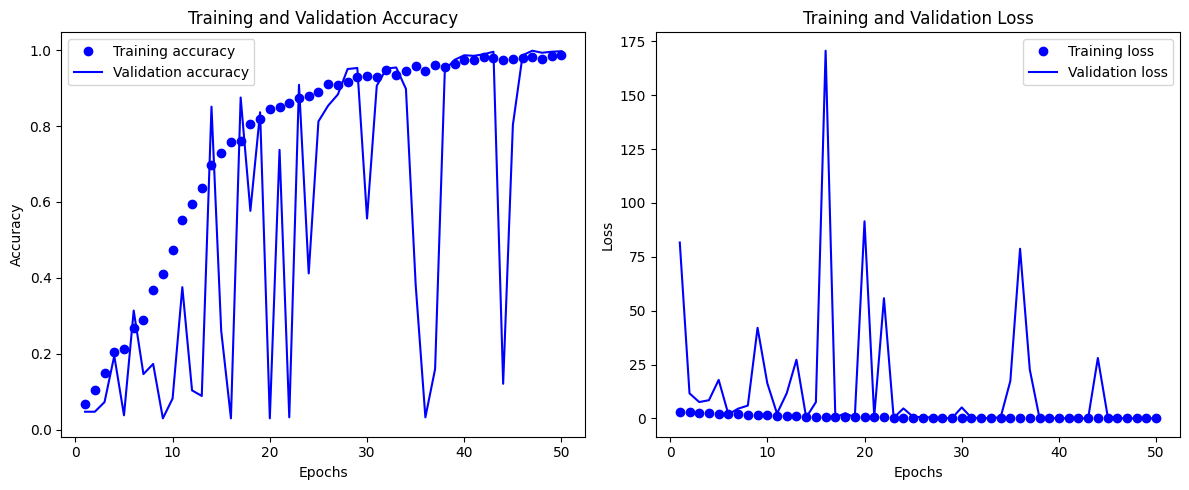

In [ ]:
import matplotlib.pyplot as plt

# Get the history data
history_dict = history.history

# Get the number of epochs
epochs = range(1, len(history_dict['loss']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

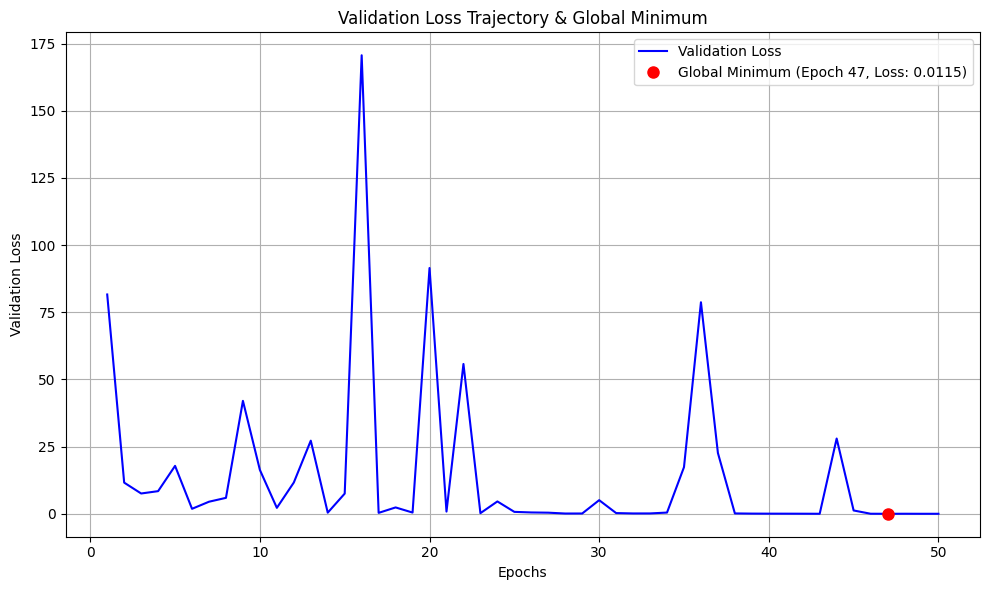

In [ ]:
import matplotlib.pyplot as plt

# Get the history data
history_dict = history.history

# Get the number of epochs
epochs = range(1, len(history_dict['val_loss']) + 1)

# Find the global minimum of validation loss
min_val_loss = min(history_dict['val_loss'])
min_val_loss_epoch = history_dict['val_loss'].index(min_val_loss) + 1

plt.figure(figsize=(10, 6))
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation Loss')
plt.plot(min_val_loss_epoch, min_val_loss, 'ro', markersize=8, label=f'Global Minimum (Epoch {min_val_loss_epoch}, Loss: {min_val_loss:.4f})')
plt.title('Validation Loss Trajectory & Global Minimum')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()